In [ ]:
#Graficar en el plano XY la curva en coordenadas polares corcorrespondiente a la función de Fey (la cual se muestra en la imagen, con el dominio correspondiente).

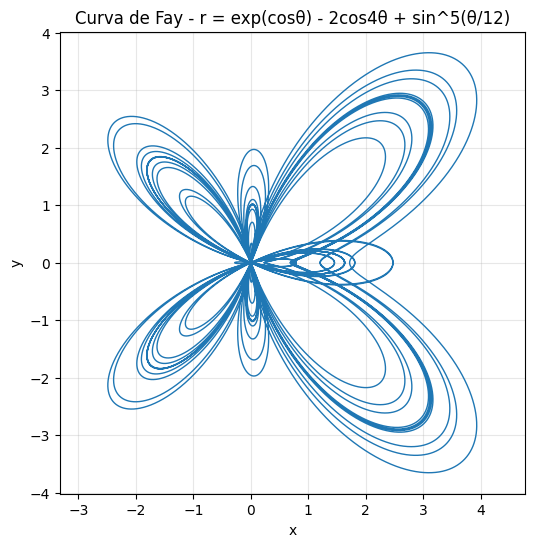

In [8]:

import numpy as np
import matplotlib.pyplot as plt

# Dominio
theta = np.linspace(0, 24*np.pi, 50000)

#La ecuacion de Fay
r = np.exp(np.cos(theta)) - 2*np.cos(4*theta) + (np.sin(theta/12))**5

# Pasar de polares (r,theta) a cartesianas (x,y) para graficar en XY
x = r * np.cos(theta)
y = r * np.sin(theta)

# 4. Graficar en plano XY
plt.figure(figsize=(6,6))
plt.plot(x, y, linewidth=1)
plt.axis('equal') # para que no se deforme la mariposa
plt.title('Curva de Fay - r = exp(cosθ) - 2cos4θ + sin^5(θ/12)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
#En una grafica de calor mostrar el potencial electroestatico de una particula con carga de 1 Coulumben el centro de un plana de un metro cuadrado.

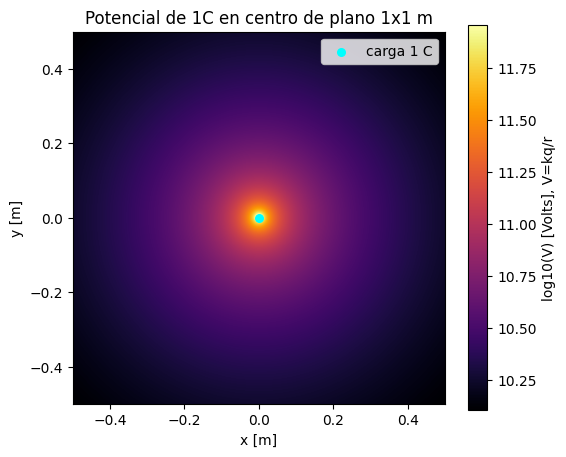

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#  CONSTANTES FISICAS
k = 8.99e9 # Constante de Coulomb en N*m^2/C^2, es la k de la formula V = kq/r
q = 1.0 # Carga de 1 Coulomb que va en el centro

# CREAR EL PLANO DE 1m x 1m
n = 400 # Numero de puntos por lado, 400x400 = 160k puntos, suficiente y no traba el kernel
x = np.linspace(-0.5, 0.5, n) # Eje x desde -0.5m a 0.5m, asi el plano mide 1 metro total y el centro queda en 0
y = np.linspace(-0.5, 0.5, n) # Eje y igual, de -0.5 a 0.5

#  CREAR LA MALLA 2D
X, Y = np.meshgrid(x, y) # Convierte los dos vectores x,y en dos matrices 2D X,Y para evaluar cada punto del plano

#  CALCULAR LA DISTANCIA r A LA CARGA
R = np.sqrt(X**2 + Y**2) # Distancia euclidiana r = sqrt(x^2 + y^2) desde cada punto (X,Y) hasta el centro (0,0)
R = np.maximum(R, 0.01) # si R=0 en el centro, V=kq/0 es infinito entonces Lo limitamos a 1cm

# FORMULA DE POTENCIAL ELECTROSTATICO
V = k * q / R # Potencial electrico V = k*q/r,

# PARA QUE SE VEA BIEN EN GRAFICA DE CALOR
V_log = np.log10(V) # 1 Coulomb genera voltajes de 10^10 Volts, es demasiado grande. Usamos log10 para comprimir la escala
V_log = np.clip(V_log, 9, 12) # Recortamos valores para que el mapa de colores no se vea todo blanco en el centro

# GRAFICAR MAPA DE CALOR
plt.figure(figsize=(6,5)) # Crea figura de 6x5 pulgadas
plt.imshow(V_log, extent=[-0.5,0.5,-0.5,0.5], origin='lower', cmap='inferno') # imshow dibuja matriz como imagen de calor
# extent dice que limites tiene en metros, origin='lower' para que el 0,0 no se voltee, cmap='inferno' es la paleta amarillo-rojo-negro

plt.colorbar(label='log10(V) [Volts], V=kq/r') # Barra de colores a la derecha que explica que color = que voltaje
plt.title('Potencial de 1C en centro de plano 1x1 m') # Titulo
plt.xlabel('x [m]') # Etiqueta eje x
plt.ylabel('y [m]') # Etiqueta eje y
plt.scatter([0],[0], c='cyan', s=30, label='carga 1 C') # Dibuja un puntito cyan en el centro para marcar donde esta la carga
plt.legend() # Muestra la leyenda del puntito
plt.show() # Muestra todo